# E-Commerce — Customer Segmentation

Group the 989 customers into actionable segments using two complementary lenses:

1. **Frequency–Monetary (FM) scoring** — an interpretable, rules-based split.
2. **K-Means clustering** — a data-driven grouping on standardized features.

> Recency (the *R* in classic RFM) is intentionally left out: the order dates run
> to 2035 (see notebook 02), so time-since-last-order isn't trustworthy here.

## 1. Setup and build the customer table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from dataanalyst.data import load_processed, save_processed
from dataanalyst.analysis import customer_features

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
orders = load_processed("ecommerce_clean.parquet")
customers = customer_features(orders)
customers.head()

,n_orders,total_revenue,avg_order_value,avg_rating
customer_id,,,,
1000,9,6905.58,767.286667,2.633333
1001,6,3959.74,659.956667,2.666667
1002,4,1579.67,394.917500,3.800000
1003,2,2304.44,1152.220000,3.000000
1004,5,6073.85,1214.770000,2.320000


In [3]:
customers.describe().round(2)

,n_orders,total_revenue,avg_order_value,avg_rating
count,989.00,989.00,989.00,989.00
mean,5.06,5166.61,1020.35,2.97
std,2.33,2952.39,408.00,0.59
min,1.00,119.06,119.06,1.00
25%,3.00,3024.67,737.19,2.60
50%,5.00,4832.82,1008.54,2.98
75%,6.00,6983.14,1268.89,3.34
max,14.00,17680.69,2890.44,4.90


## 2. Distribution of frequency and monetary value

Understand the spread before segmenting.

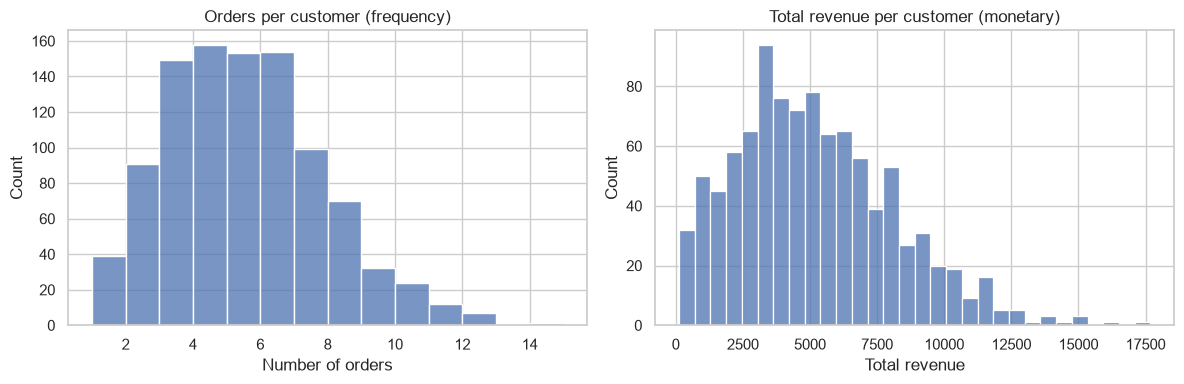

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(customers["n_orders"], bins=range(1, 16), ax=axes[0])
axes[0].set_title("Orders per customer (frequency)")
axes[0].set_xlabel("Number of orders")
sns.histplot(customers["total_revenue"], bins=30, ax=axes[1])
axes[1].set_title("Total revenue per customer (monetary)")
axes[1].set_xlabel("Total revenue")
plt.tight_layout()
plt.show()

## 3. Frequency–Monetary segmentation

Score each customer 1–4 on frequency and monetary value (quartiles), then map the
combination to a business segment.

In [5]:
# Quartile scores (1 = lowest, 4 = highest). Rank breaks ties for the discrete
# frequency column so qcut can form four equal groups.
customers["F_score"] = pd.qcut(customers["n_orders"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
customers["M_score"] = pd.qcut(customers["total_revenue"], 4, labels=[1, 2, 3, 4]).astype(int)

def segment(row):
    high_f = row["F_score"] >= 3
    high_m = row["M_score"] >= 3
    if high_f and high_m:
        return "Champions"
    if high_f and not high_m:
        return "Loyal (lower value)"
    if not high_f and high_m:
        return "Big spenders"
    return "Occasional"

customers["segment"] = customers.apply(segment, axis=1)
customers["segment"].value_counts()

segment
Occasional             395
Champions              394
Loyal (lower value)    100
Big spenders           100
Name: count, dtype: int64

In [6]:
segment_summary = customers.groupby("segment").agg(
    customers=("total_revenue", "size"),
    total_revenue=("total_revenue", "sum"),
    avg_revenue=("total_revenue", "mean"),
    avg_orders=("n_orders", "mean"),
).sort_values("total_revenue", ascending=False)
segment_summary["revenue_share_%"] = (100 * segment_summary["total_revenue"] / segment_summary["total_revenue"].sum()).round(1)
segment_summary.round(1)

,customers,total_revenue,avg_revenue,avg_orders,revenue_share_%
segment,,,,,
Champions,394,3109281.8,7891.6,7.2,60.8
Occasional,395,1010194.8,2557.5,3.0,19.8
Big spenders,100,610253.0,6102.5,4.1,11.9
Loyal (lower value),100,380046.1,3800.5,5.8,7.4


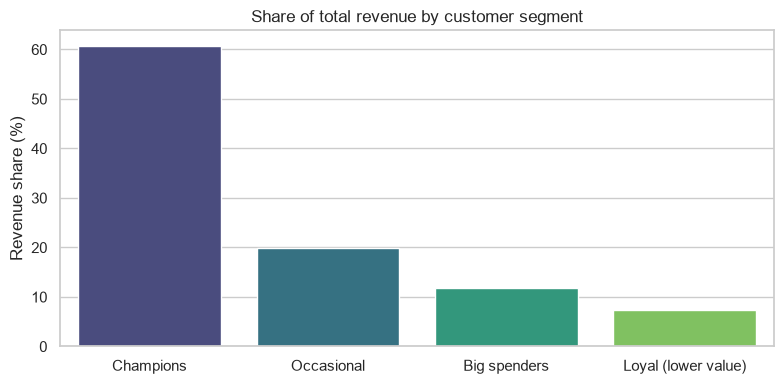

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=segment_summary.index, y=segment_summary["revenue_share_%"], ax=ax,
            hue=segment_summary.index, palette="viridis", legend=False)
ax.set_title("Share of total revenue by customer segment")
ax.set_xlabel("")
ax.set_ylabel("Revenue share (%)")
plt.tight_layout()
plt.show()

## 4. K-Means clustering

A data-driven alternative: standardize the customer features and let K-Means find
natural groupings. We use k = 4 to compare against the FM segments.

In [8]:
feature_cols = ["n_orders", "total_revenue", "avg_order_value", "avg_rating"]
X = StandardScaler().fit_transform(customers[feature_cols])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customers["cluster"] = kmeans.fit_predict(X)
customers["cluster"].value_counts().sort_index()

cluster
0    214
1    298
2    173
3    304
Name: count, dtype: int64

In [9]:
# Profile each cluster by its average feature values
cluster_profile = customers.groupby("cluster")[feature_cols].mean().round(1)
cluster_profile["size"] = customers["cluster"].value_counts().sort_index()
cluster_profile

,n_orders,total_revenue,avg_order_value,avg_rating,size
cluster,,,,,
0,3.8,3388.4,910.1,3.7,214
1,7.8,8307.2,1083.8,3.0,298
2,4.0,5956.9,1555.4,2.7,173
3,4.0,2890.0,731.3,2.6,304


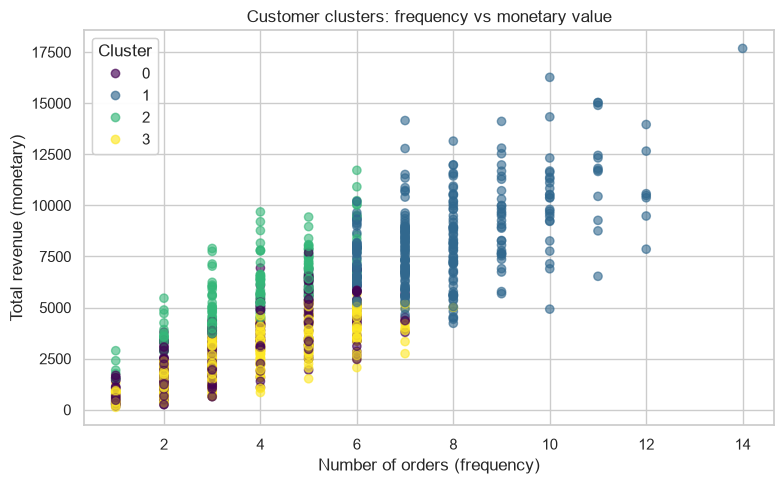

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(customers["n_orders"], customers["total_revenue"],
                     c=customers["cluster"], cmap="viridis", alpha=0.6)
ax.set_title("Customer clusters: frequency vs monetary value")
ax.set_xlabel("Number of orders (frequency)")
ax.set_ylabel("Total revenue (monetary)")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## 5. Save the segmented customer table

In [11]:
save_processed(customers.reset_index(), "customer_segments.parquet")

WindowsPath('D:/Work/self-project/dataAnalyst/data/processed/customer_segments.parquet')

## 6. Segments and recommendations

- **Champions** (high frequency *and* high spend) are the revenue core — protect them
  with loyalty perks, early access, and referral incentives.
- **Big spenders** (high value, lower frequency) have room to buy more often —
  target with replenishment reminders and cross-sell of complementary categories.
- **Loyal (lower value)** buy often but spend little per order — nudge basket size
  with bundles and thresholds for free shipping.
- **Occasional** customers are low on both axes — win-back campaigns and onboarding
  offers; keep acquisition cost for this group in check.

The K-Means clusters tell a consistent story on the frequency×monetary plane, giving
an independent, data-driven confirmation of the rules-based FM segments.

**Caveat:** without reliable recency, these segments describe *value and frequency*,
not churn risk. Adding validated order dates would enable full RFM and lifecycle analysis.